# Google Colab Setup

Please run the code below to mount drive if you are running on colab.

Please ignore if you are running on your local machine.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Language Modeling and Transformers

The project will consist of two broad parts.

1. **Baseline Generative Language Model**: We will train a simple Bigram language model on the text data. We will use this model to generate a mini story.
2. **Implementing Mini GPT**: We will implement a mini version of the GPT model layer by layer and attempt to train it on the text data. You will then load pretrained weights provided and generate a mini story.

## Some general instructions

1. Please keep the name of layers consistent with what is requested in the `model.py` file for each layer, this helps us test in each function independently.
2. Please check to see if the bias is to be set to false or true for all linear layers (it is mentioned in the doc string)
3. As a general rule please read the docstring well, it contains information you will need to write the code.
4. All configs are defined in `config.py` for the first part. While you are writing the code, do not change the values in the config file since we use them to test. Once you have passed all the tests please feel free to vary the parameter as you please.
5. You will need to fill in `train.py` and run it to train the model. If you are running into memory issues please feel free to change the `batch_size` in the `config.py` file. If you are working on Colab please make sure to use the GPU runtime and feel free to copy over the training code to the notebook.

In [2]:
!git clone https://github.com/SamuelLo1/Deep-Learning-Notebooks.git

Cloning into 'Deep-Learning-Notebooks'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 272 (delta 13), reused 29 (delta 11), pack-reused 235 (from 1)
Receiving objects: 100% (272/272), 5.40 MiB | 31.43 MiB/s, done.
Resolving deltas: 100% (115/115), done.


In [3]:
%cd Deep-Learning-Notebooks/


/content/Deep-Learning-Notebooks


In [5]:
!git pull origin miniGPT


From https://github.com/SamuelLo1/Deep-Learning-Notebooks
 * branch            miniGPT    -> FETCH_HEAD
Already up to date.


In [4]:
!git checkout miniGPT

Branch 'miniGPT' set up to track remote branch 'miniGPT' from 'origin'.
Switched to a new branch 'miniGPT'


In [6]:
%cd MiniGPTStudentVersion/

/content/Deep-Learning-Notebooks/MiniGPTStudentVersion


In [7]:
!pip install numpy torch tiktoken wandb einops # Install all required packages

In [ ]:
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [8]:
import torch
import tiktoken

In [9]:
from model import BigramLanguageModel, SingleHeadAttention, MultiHeadAttention, FeedForwardLayer, LayerNorm, TransformerLayer, MiniGPT
from config import BigramConfig, MiniGPTConfig
import tests

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# If not provided, download from https://drive.google.com/file/d/1g09qUM9WibdfQVgkj6IAj8K2S3SGwc91/view?usp=sharing
path_to_bigram_tester = "/content/drive/MyDrive/MiniGPT/pretrained_models/bigram_tester.pt" # Load the bigram model with name bigram_tester.pt
path_to_gpt_tester = "/content/drive/MyDrive/MiniGPT/pretrained_models/minigpt_tester.pt" # Load the gpt model with name minigpt_tester.pt

##  Bigram Language Model (10 points)

A bigram language model is a type of probabilistic language model that predicts a word given the previous word in the sequence. The model is trained on a text corpus and learns the probability of a word given the previous word.



### Implement the Bigram model (5 points)

Please complete the `BigramLanguageModel` class in model.py. We will model a Bigram language model using a simple MLP with one hidden layer. The model will take in the previous word index and output the logits over the vocabulary for the next word.

In [13]:
# Test implementation for Bigram Language Model
model = BigramLanguageModel(BigramConfig)
tests.check_bigram(model, path_to_bigram_tester, device)

'TEST CASE PASSED!!!'

### Training the Bigram Language Model (2.5 points)

Complete the code in `train.py` to train the Bigram language model on the text data. Please provide plots for both the training and validation in the cell below.

Some notes on the training process:

1. You should be able to train the model slowly on your local machine.
2. Training it on Colab will help with speed.
3.  <span style="color:red">To get full points for this section it is sufficient to show that the loss is decreasing over time</span>. You should see it saturate to a value close to around 5-6 but as long as you see it decreasing then saturating you should be good.
4. Please log the loss curves either on wandb, tensorboard or any other logger of your choice and please attach them below.

In [14]:
from train import solver

In [ ]:
solver(model_name="bigram")

### Train and Valid Plots


** Show the training and validation loss plots **

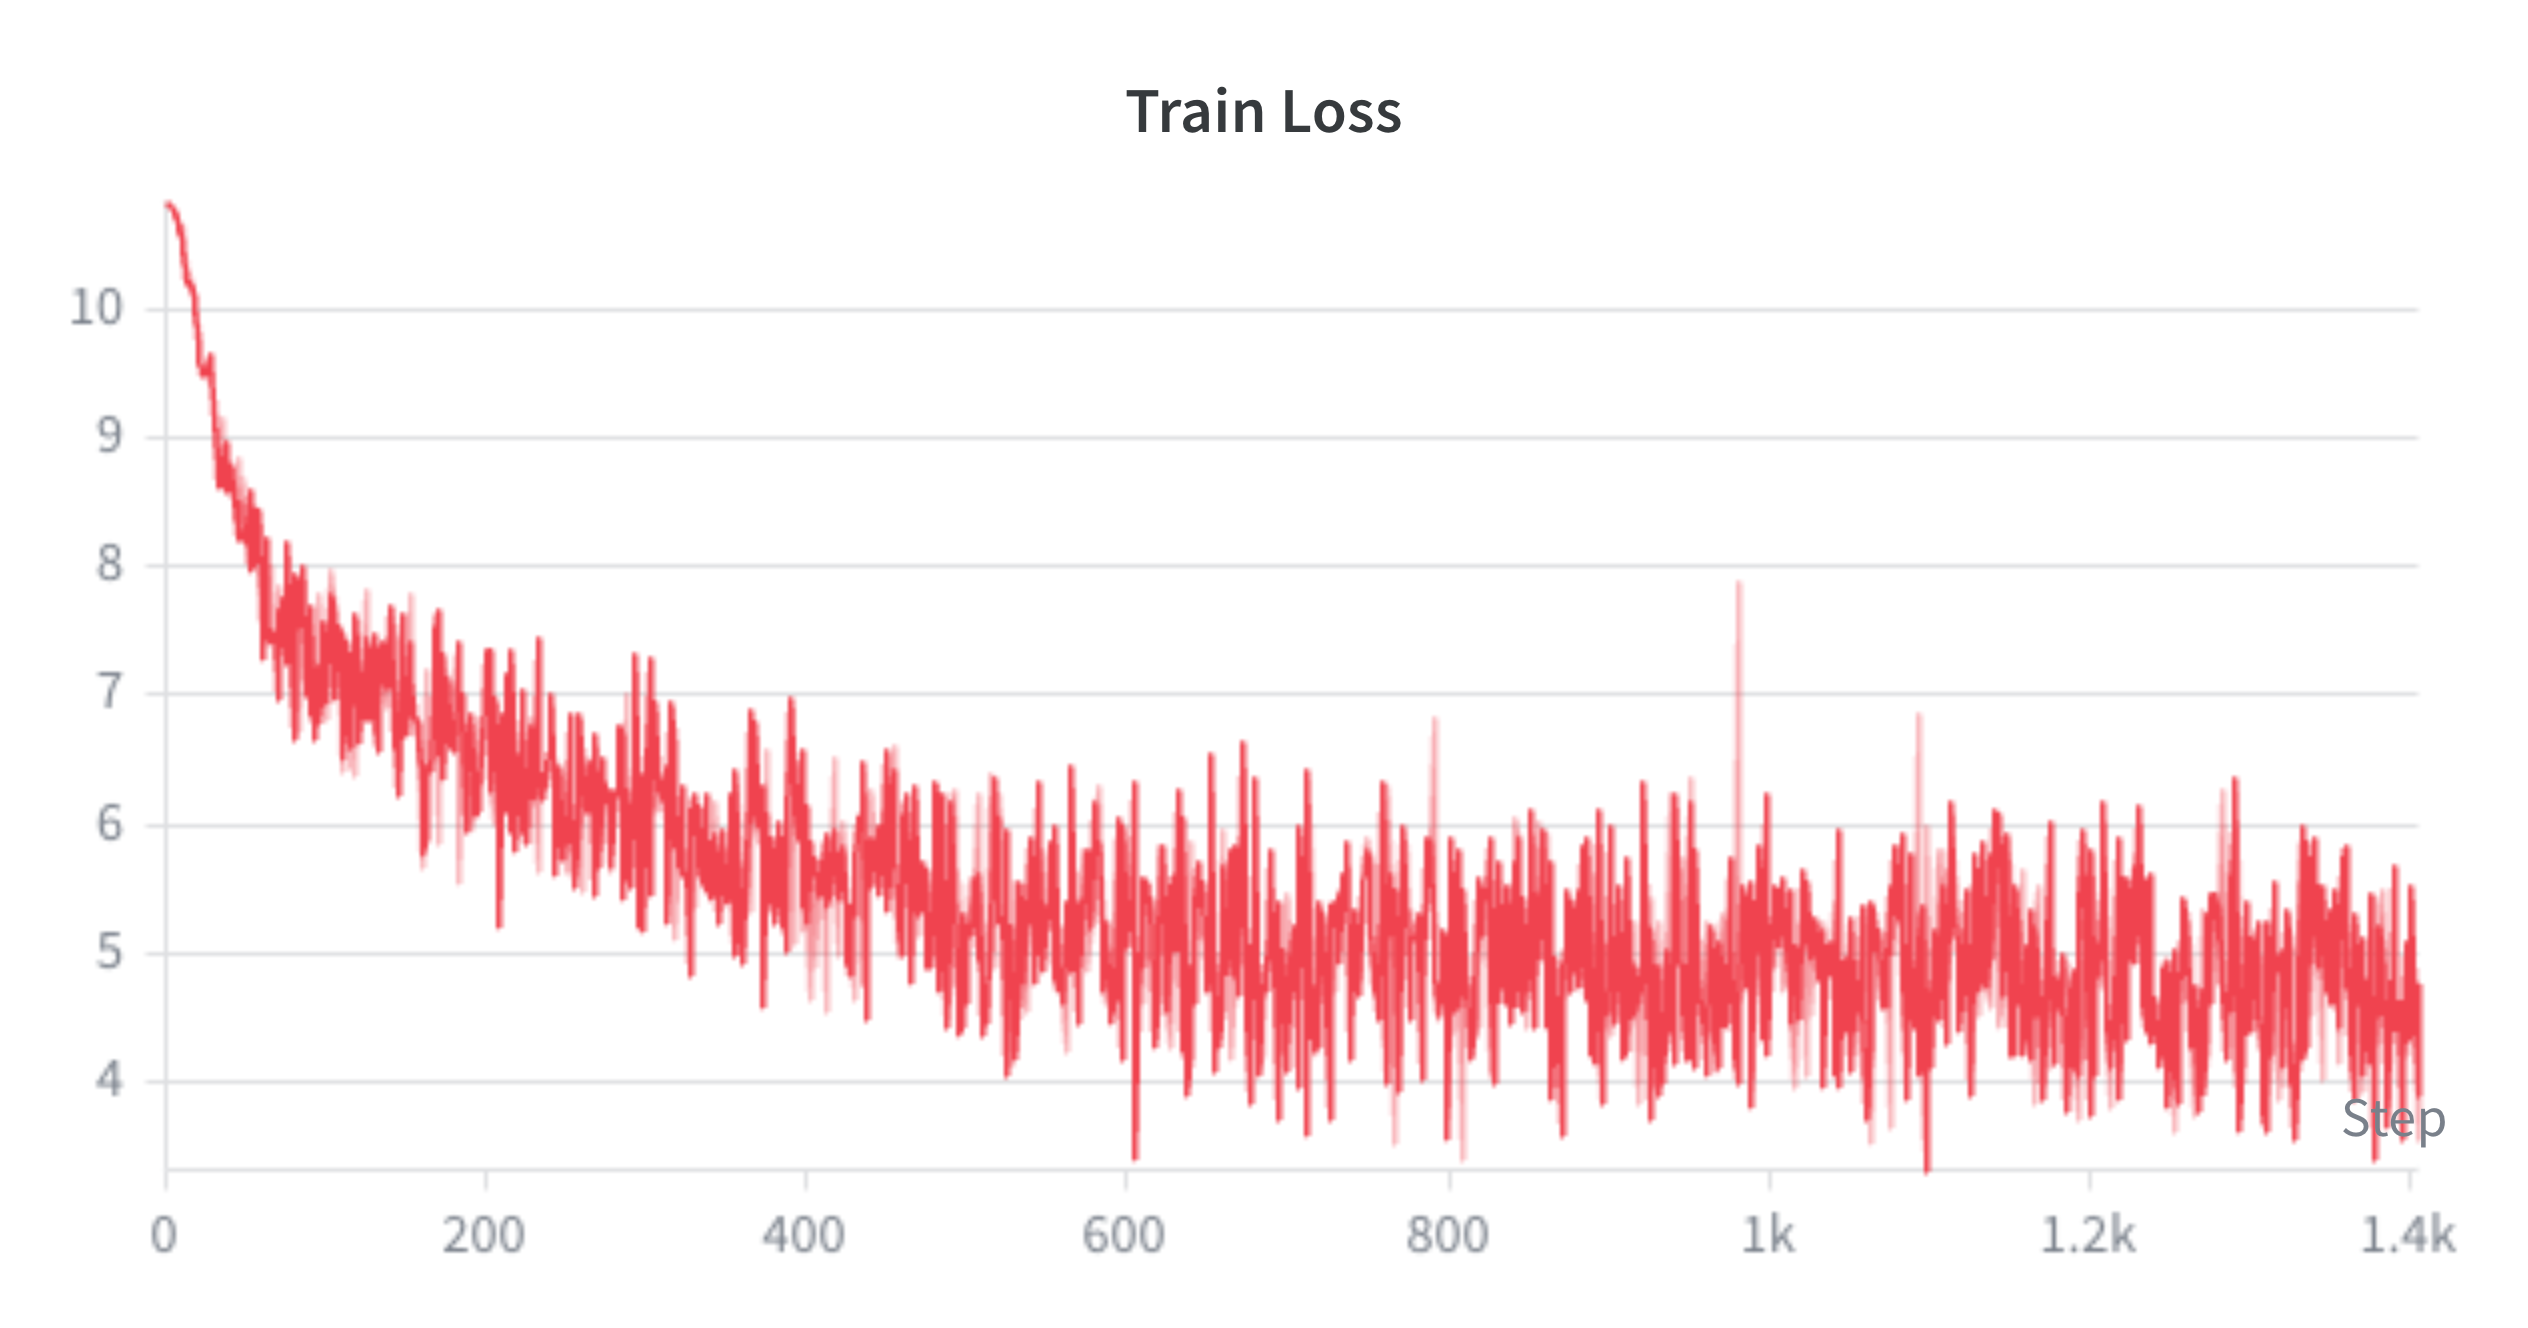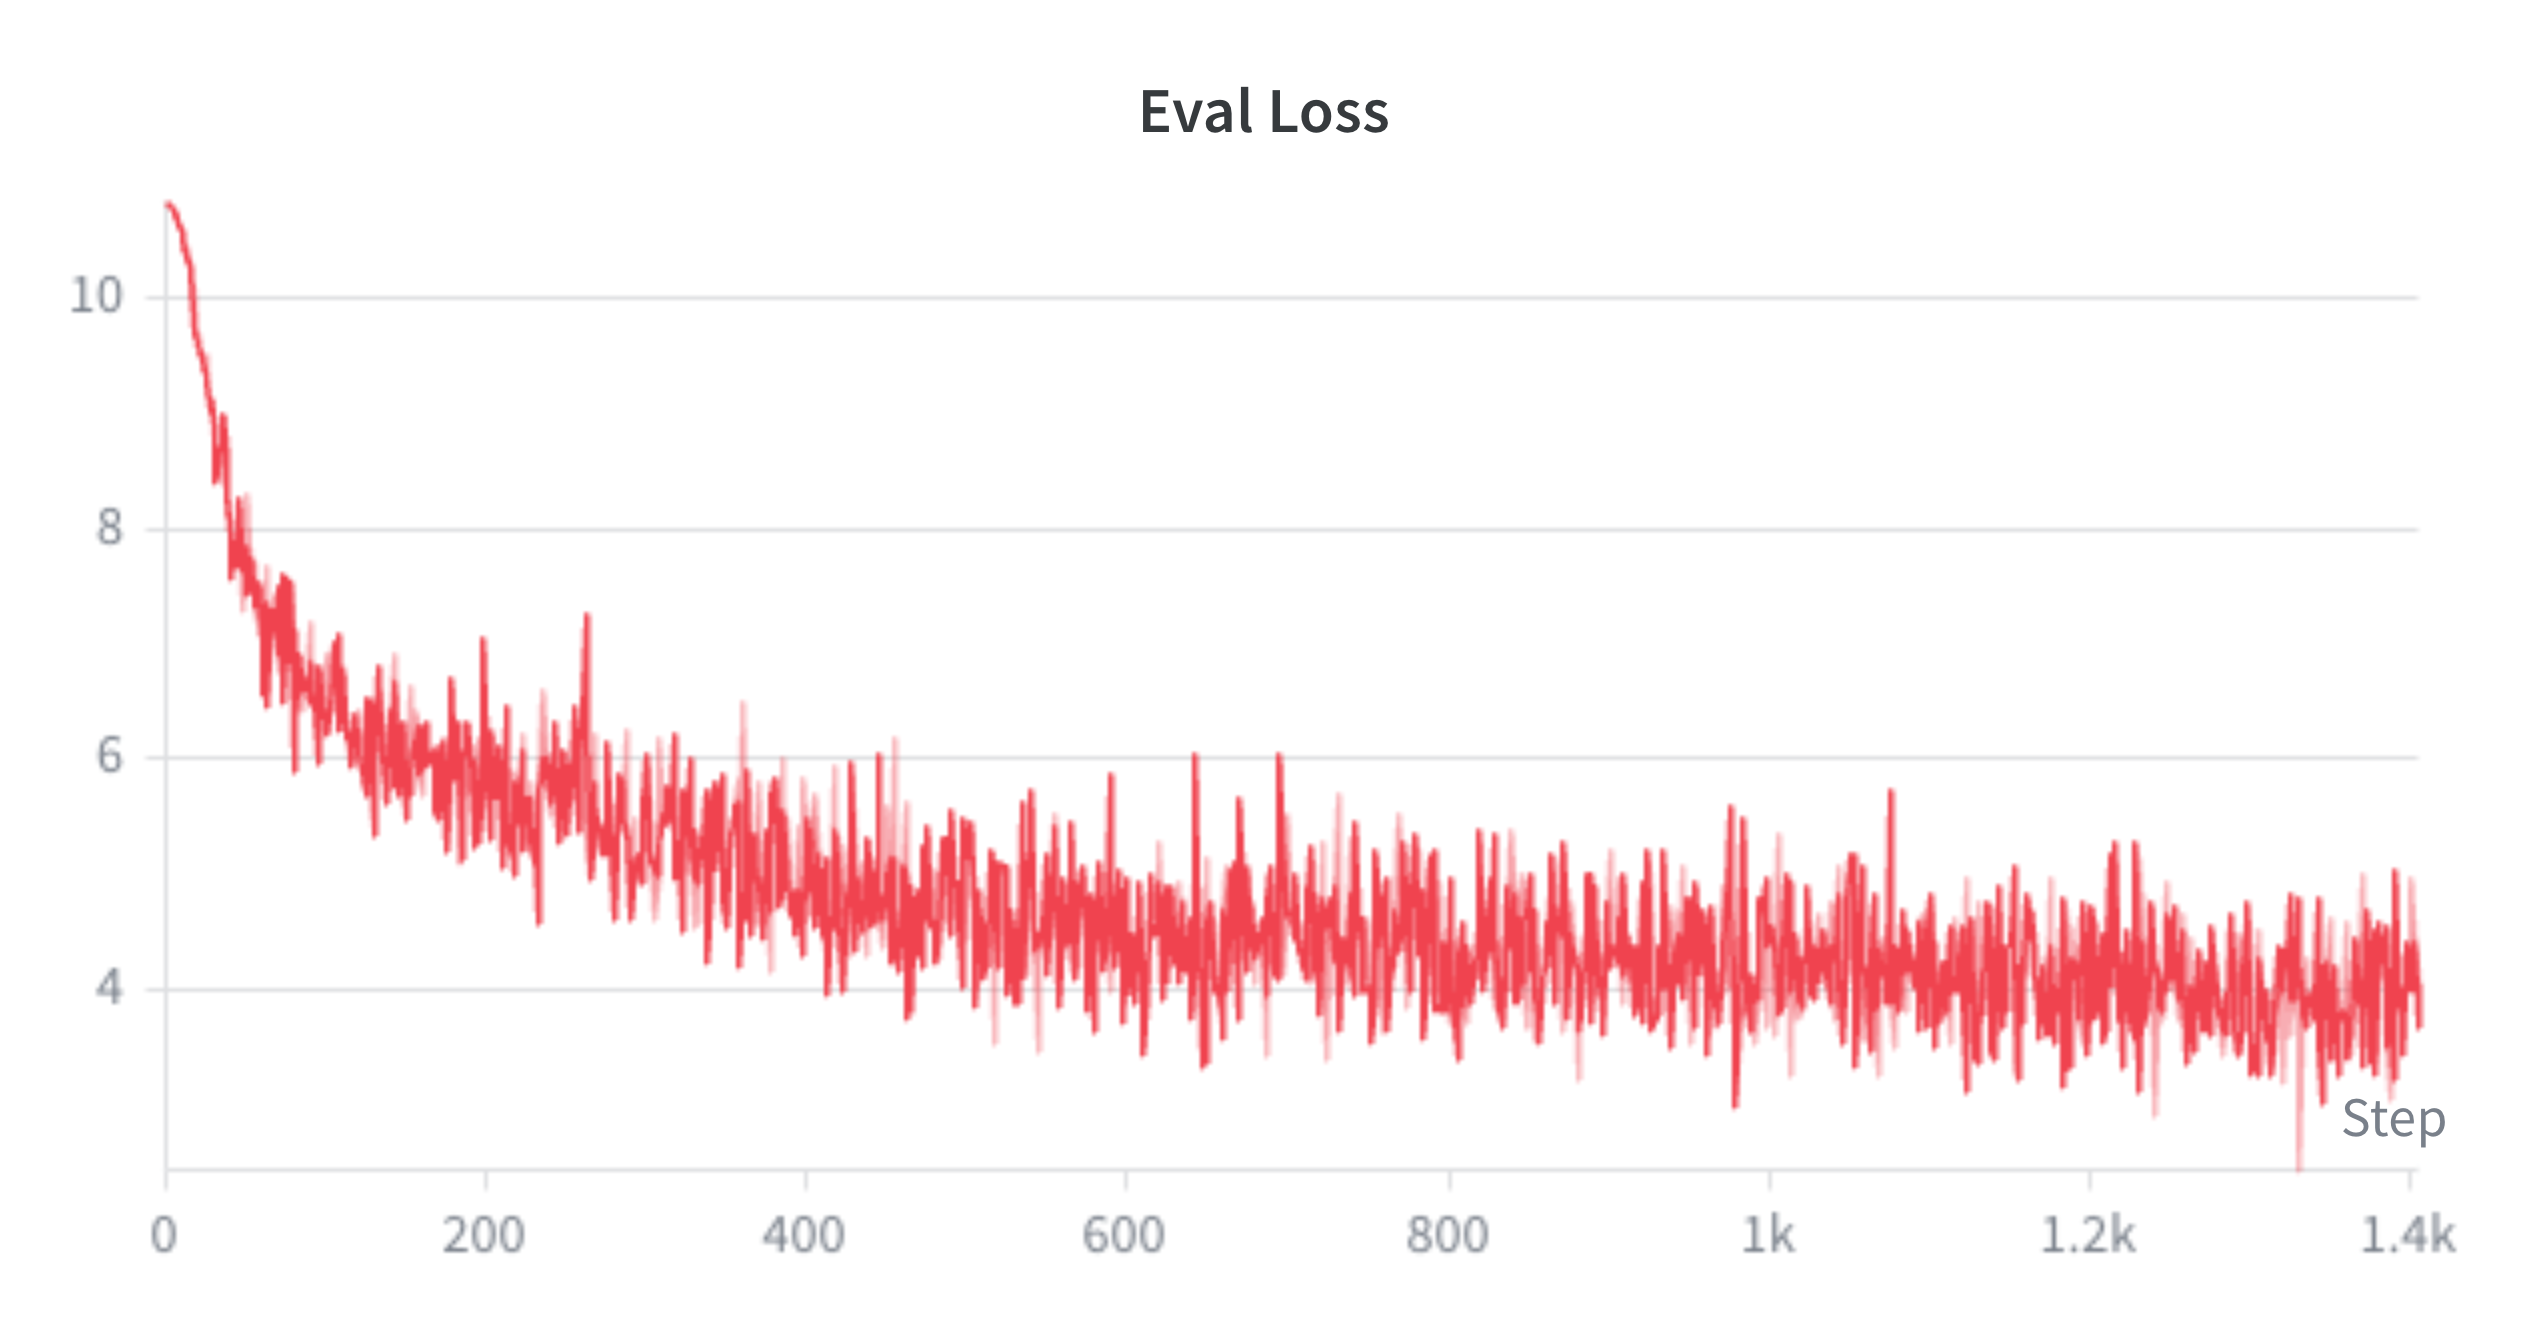

### Generation (2.5 points)

Complete the code in the `generate` method of the Bigram class and generate a mini story using the trained Bigram language model. The model will take in the previous word index and output the next word index.

Start with the following seed sentence:
    
    `"once upon a time"`
    

In [ ]:
# TODO: Specify the path to your trained model
model_path = "/content/Deep-Learning-Notebooks/MiniGPTStudentVersion/models/bigram/mini_model_checkpoint_90000.pt"
model = BigramLanguageModel(BigramConfig)
tokenizer = tiktoken.get_encoding("gpt2")
model.load_state_dict(torch.load(model_path)["model_state_dict"])

<All keys matched successfully>

In [ ]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
print(
    tokenizer.decode(
        model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
    )
)

Generating text starting with: torch.Size([4])
Once upon a time tree. hipp went to buy looked singing excited.
" calling jumped screamed friends. We jumped in who hugged her mom was good owner away. We did not home and always also up. So, something knee explore wet. find other up his bike and couldn't grow again. He kitten kind hill! They were things of far more grandYes, you an.
After," had so safe who was no more unexpected find its better. So!"
Lily thought the house on it was fun there was very necklace across! It was brother, Lily and hugged her mom and play the woods and he found a mistake for hugs green to open her very something tried is girl wanted to go with fight, there will shop. Then them all day and didn't 
But. Tim's friends.Once upon a sign. Lily were proud of hammer in the cat was apy that she listened to you bed here a rabbit. They had the toy large puzzles grow she found a time, Tom was


### Observation and Analysis

Please answer the following questions.

1. What can we say about the generated text in terms of grammar and coherence?
2. What are the limitations of the Bigram language model?
3. If the model is scaled with more parameters do you expect the bigram model to get substantially better? Why or why not?

## Mini GPT (90 points)

We will implement a decoder style transformer model like we discussed in lecture, which is a scaled down version of the [GPT model](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf).

All the model components follow directly from the original [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper. The only difference is we will use prenormalization and learnt positional embeddings instead of fixed ones.

We will now implement each layer step by step checking if it is implemented correctly in the process. We will finally put together all our layers to get a fully fledged GPT model.

<span style="color:red">Later layers might depend on previous layers so please make sure to check the previous layers before moving on to the next one.</span>

### Single Head Causal Attention (20 points)

We will first implement the single head causal attention layer. This layer is the same as the scaled dot product attention layer but with a causal mask to prevent the model from looking into the future.

Recall that Each head has a Key, Query and Value Matrix and the scaled dot product attention is calculated as :

\begin{equation}
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\end{equation}

where $d_k$ is the dimension of the key matrix.

Figure below from the original paper shows how the layer is to be implemented.

![image](https://github.com/SamuelLo1/Deep-Learning-Notebooks/blob/miniGPT/MiniGPTStudentVersion/Images/Single_Head.png?raw=1)

Image credits: [Attention is All You Need Paper](https://arxiv.org/abs/1706.03762)

Please complete the `SingleHeadAttention` class in `model.py`

In [10]:
model = SingleHeadAttention(MiniGPTConfig.embed_dim, MiniGPTConfig.embed_dim//4, MiniGPTConfig.embed_dim//4) # configs are set as such for testing do not modify
tests.check_singleheadattention(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Multi Head Attention (10 points)

Now that we have a single head working, we will now scale this across multiple heads, remember that with multihead attention we compute perform head number of parallel attention operations. We then concatenate the outputs of these parallel attention operations and project them back to the desired dimension using an output linear layer.

Figure below from the original paper shows how the layer is to be implemented.

![image](https://github.com/SamuelLo1/Deep-Learning-Notebooks/blob/miniGPT/MiniGPTStudentVersion/Images/MultiHead.png?raw=1)

Image credits: [Attention is All You Need Paper](https://arxiv.org/abs/1706.03762)

Please complete the `MultiHeadAttention` class in `model.py` using the `SingleHeadAttention` class implemented earlier.

In [9]:
model = MultiHeadAttention(MiniGPTConfig.embed_dim, MiniGPTConfig.num_heads)
tests.check_multiheadattention(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Feed Forward Layer (5 points)

As discussed in lecture, the attention layer is completely linear, in order to add some non-linearity we add a feed forward layer. The feed forward layer is a simple two layer MLP with a GeLU activation in between.

Please complete the `FeedForwardLayer` class in `model.py`

In [10]:
model = FeedForwardLayer(MiniGPTConfig.embed_dim)
tests.check_feedforward(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### LayerNorm (10 points)

We will now implement the layer normalization layer. Layernorm is used across the model to normalize the activations of the previous layer. Recall that the equation for layernorm is given as:

\begin{equation}

\text{LayerNorm}(x) = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \odot \gamma + \beta

\end{equation}

With the learnable parameters $\gamma$ and $\beta$.

Remember that unlike batchnorm we compute statistics across the feature dimension and not the batch dimension, hence we do not need to keep track of running averages.

Please complete the `LayerNorm` class in `model.py`

In [12]:
model = LayerNorm(MiniGPTConfig.embed_dim)
tests.check_layernorm(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Transformer Layer (15 points)

We have now implemented all the components of the transformer layer. We will now put it all together to create a transformer layer. The transformer layer consists of a multi head attention layer, a feed forward layer and two layer norm layers.

Please use the following order for each component (Varies slightly from the original attention paper):
1. LayerNorm
2. MultiHeadAttention
3. LayerNorm
4. FeedForwardLayer

Remember that the transformer layer also has residual connections around each sublayer.

The below figure shows the structure of the transformer layer you are required to implement.

![prenorm_transformer](https://github.com/SamuelLo1/Deep-Learning-Notebooks/blob/miniGPT/MiniGPTStudentVersion/Images/Prenorm.png?raw=1)

Image Credit : [CogView](https://arxiv.org/pdf/2105.13290)

Implement the `TransformerLayer` class in `model.py`

In [9]:
model =  TransformerLayer(MiniGPTConfig.embed_dim, MiniGPTConfig.num_heads)
tests.check_transformer(model, path_to_gpt_tester, device)

Check output shape: torch.Size([10, 10, 64])
Old output shape: torch.Size([10, 10, 64])
max absolute difference: tensor(7.1526e-07, device='cuda:0', grad_fn=<MaxBackward1>)


'TEST CASE PASSED!!!'

### Putting it all together : MiniGPT (15 points)

We are now ready to put all our layers together to build our own MiniGPT!

The MiniGPT model consists of an embedding layer, a positional encoding layer and a stack of transformer layers. The output of the transformer layer is passed through a linear layer (called head) to get the final output logits. Note that in our implementation we will use [weight tying](https://arxiv.org/abs/1608.05859) between the embedding layer and the final linear layer. This allows us to save on parameters and also helps in training.

Implement the `MiniGPT` class in `model.py`

In [11]:
model = MiniGPT(MiniGPTConfig)
tests.check_miniGPT(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Attempt at training the model (5 points)

We will now attempt to train the model on the text data. We will use the same text data as before. If needed, you can scale down the model parameters in the config file to a smaller value to make training feasible.

Use the same training script we built for the Bigram model to train the MiniGPT model. If you implemented it correctly it should work just out of the box!

**NOTE** : We will not be able to train the model to completion in this assignment. Unfortunately, without access to a relatively powerful GPU, training a large enough model to see good generation is not feasible. However, you should be able to see the loss decreasing over time. <span style="color:red">To get full points for this section it is sufficient to show that the loss is decreasing over time</span>. You do not need to run this for more than 5000 iterations or 1 hour of training.

In [12]:
from train import solver

In [13]:
solver(model_name="minigpt")

number of trainable parameters: 3.32M


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: samuello300 (samuello300-ucla) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Iteration 0, Train Loss: 10.82724380493164 Eval Loss: 10.85352897644043
Iteration 10, Train Loss: 10.658346176147461 Eval Loss: 10.633466720581055
Iteration 20, Train Loss: 10.389747619628906 Eval Loss: 10.395271301269531
Iteration 30, Train Loss: 10.173827171325684 Eval Loss: 10.095829963684082
Iteration 40, Train Loss: 9.876677513122559 Eval Loss: 9.74474811553955
Iteration 50, Train Loss: 9.70504379272461 Eval Loss: 9.494720458984375
Iteration 60, Train Loss: 9.340513229370117 Eval Loss: 9.313567161560059
Iteration 70, Train Loss: 9.087285041809082 Eval Loss: 8.873371124267578
Iteration 80, Train Loss: 8.78080940246582 Eval Loss: 8.516846656799316
Iteration 90, Train Loss: 8.59354019165039 Eval Loss: 8.308218002319336
Iteration 100, Train Loss: 8.348450660705566 Eval Loss: 8.01898193359375
Iteration 110, Train Loss: 7.922116756439209 Eval Loss: 7.678013801574707
Iteration 120, Train Loss: 7.711042881011963 Eval Loss: 7.8715057373046875
Iteration 130, Train Loss: 7.3387980461120605 E

KeyboardInterrupt: 

### Train and Valid Plots


** Show the training and validation loss plots **

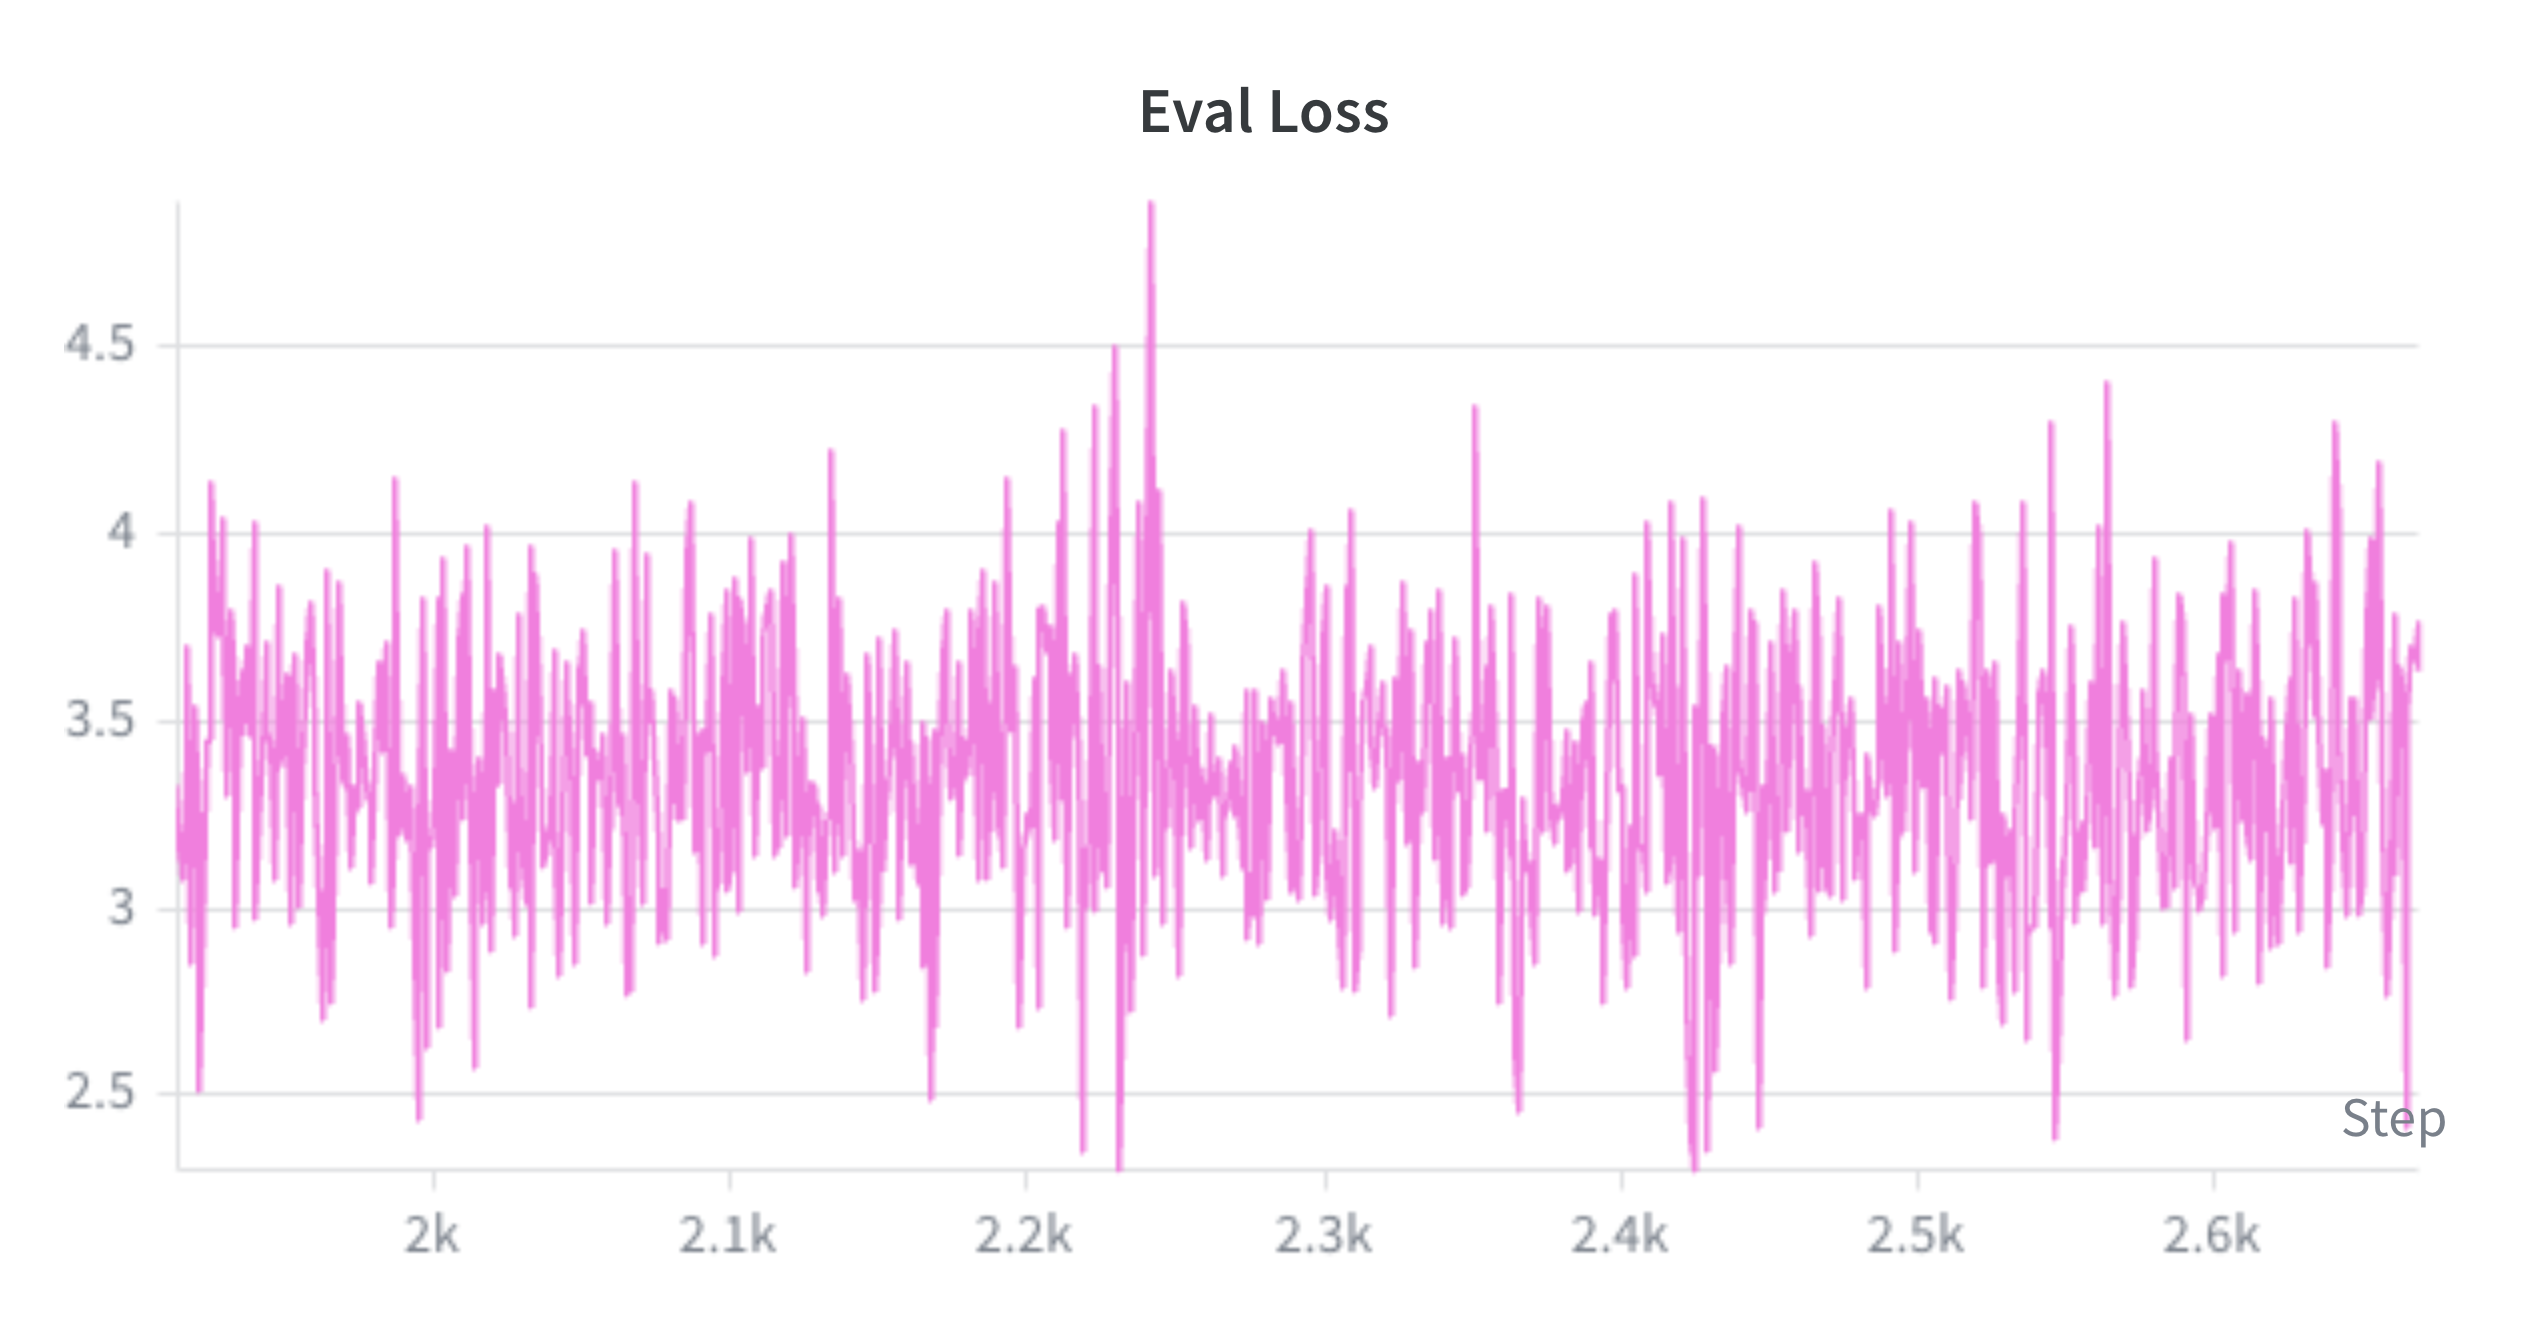

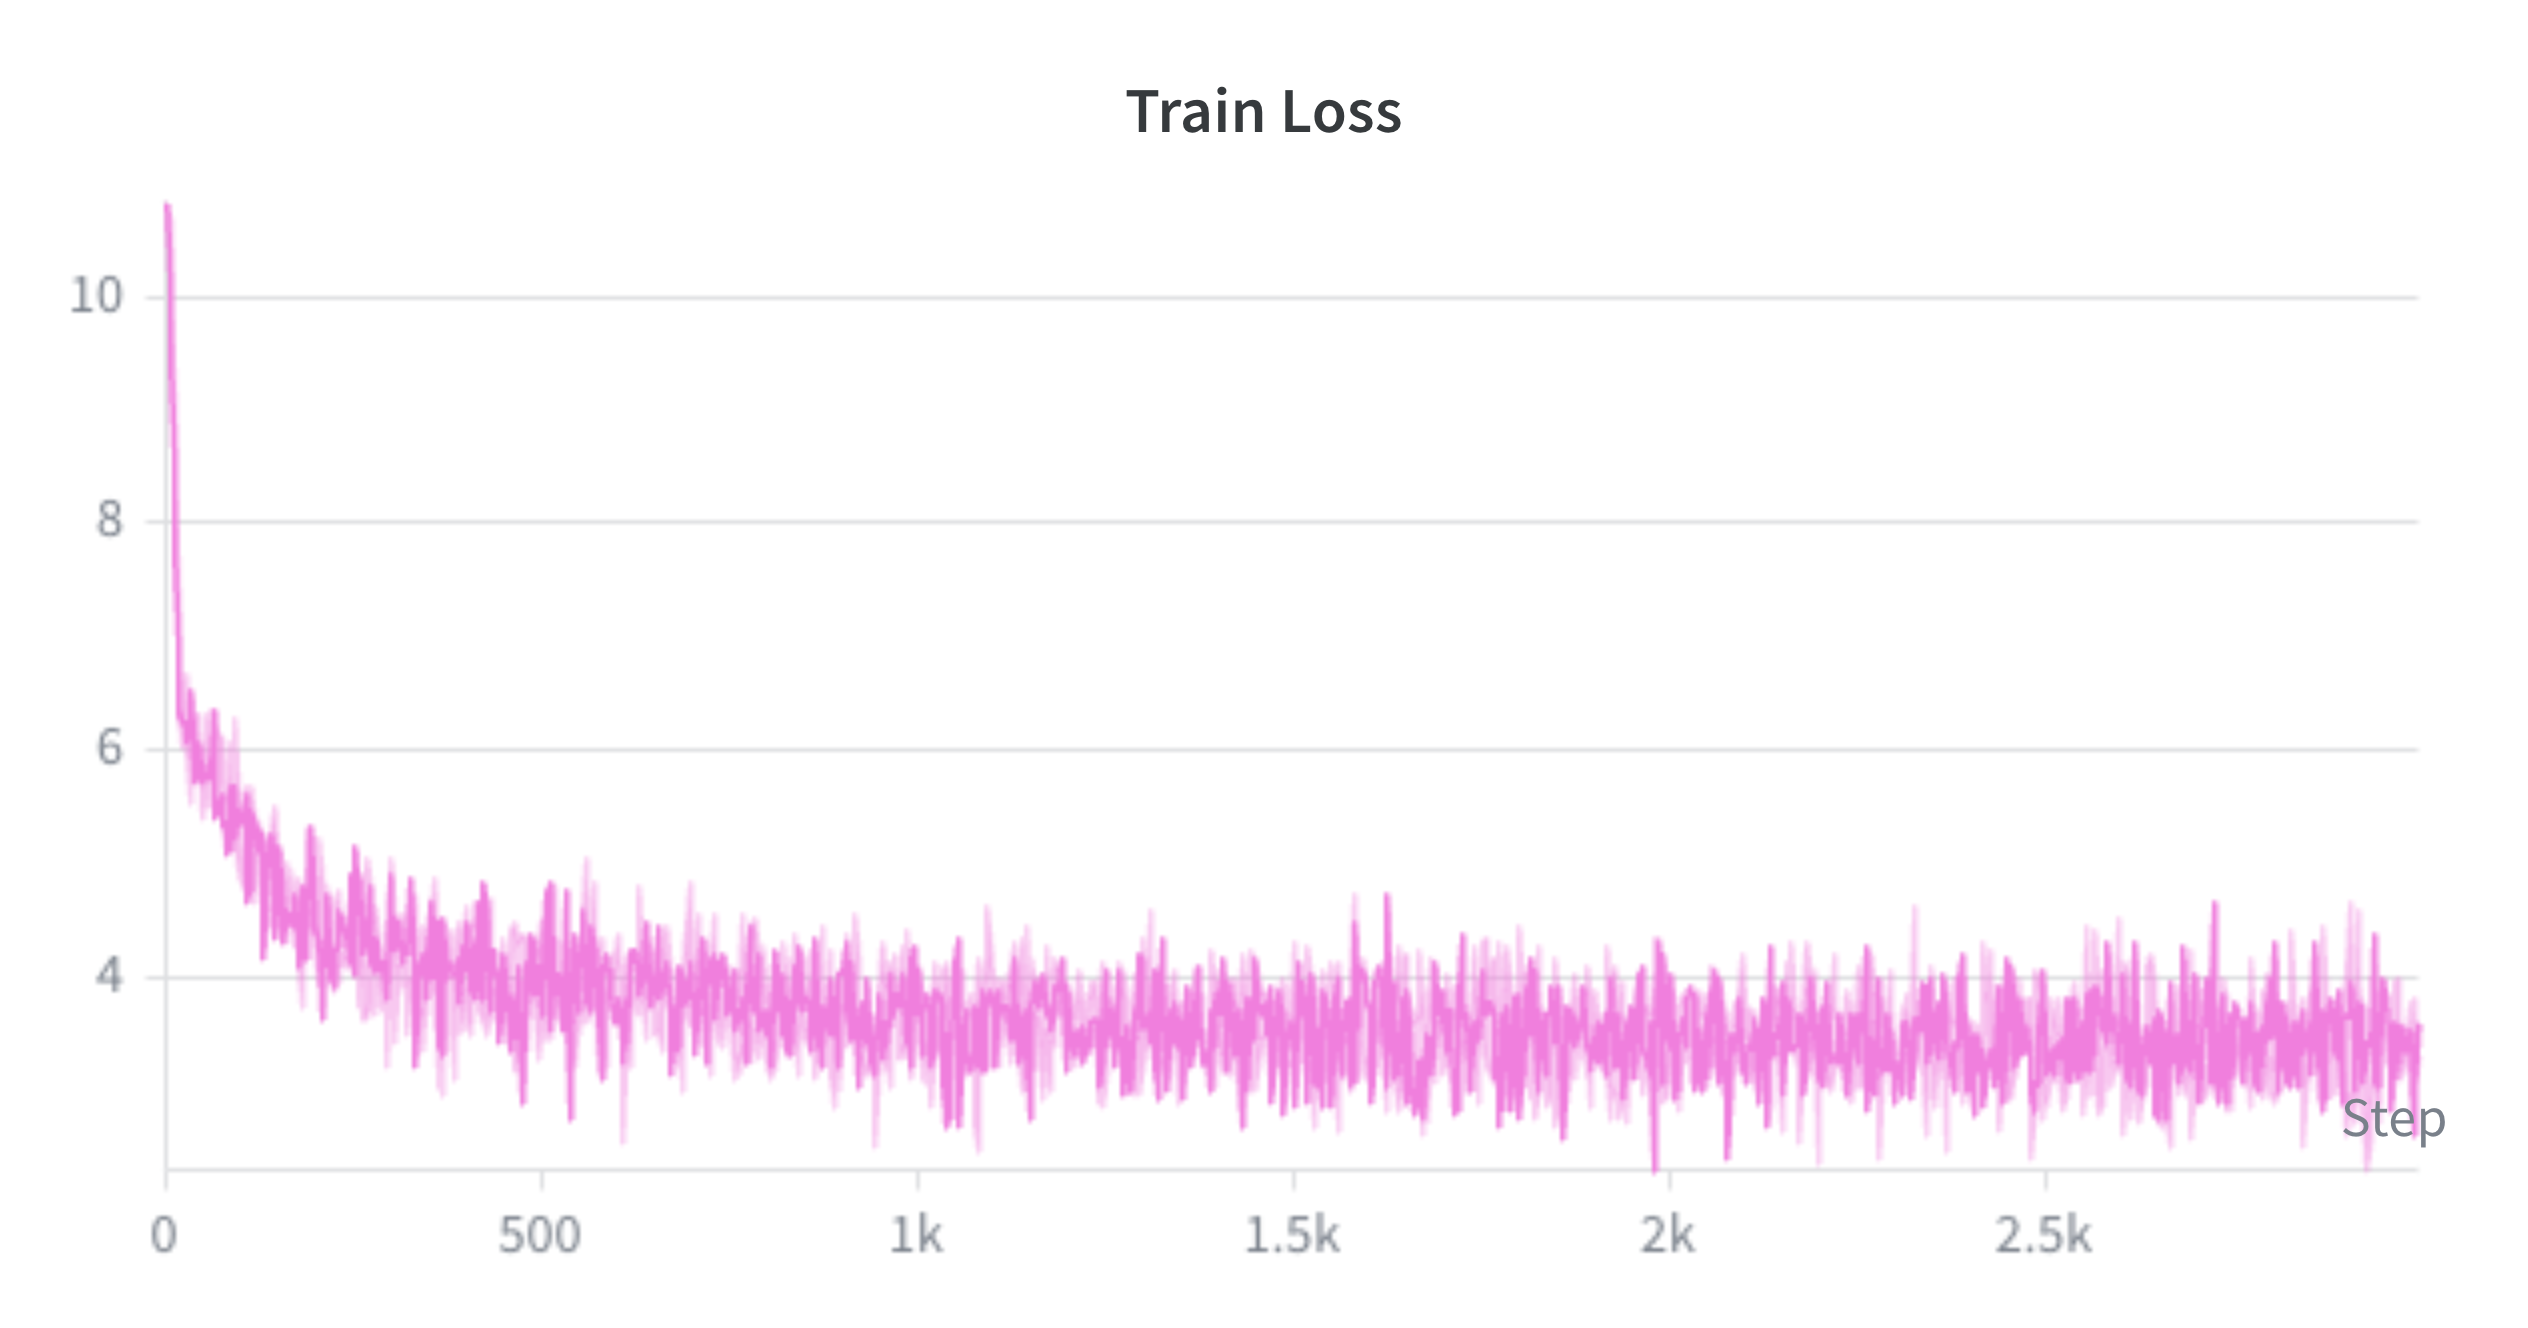

### Generation (5 points)


Perform generation with the MiniGPT model that you trained. Generate a mini story using the same seed sentence.

    `"once upon a time"`

In [12]:
# TODO: Specify the path to your trained model
model_path = "/content/drive/MyDrive/MiniGPT/mini_model_checkpoint_20000.pt"
model = MiniGPT(MiniGPTConfig)
tokenizer = tiktoken.get_encoding("gpt2")
model.load_state_dict(torch.load(model_path)["model_state_dict"])

<All keys matched successfully>

In [13]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
print(
    tokenizer.decode(
        model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
    )
)

Generating text starting with: torch.Size([4])
Once upon a time, there was a young dog named Timmy, colorful sun all day. Suddenly,, he kicked it and found a big flame muscles. He said they were successful pie.
Mama flked saw the best toy were very happy and surprised.
One day, she saw a big stamp, sad fairy was Tommy?"
At the end. But they went to go to, Timmy and tell her why her friends are going to play with the hat together. They followed the shiny cloth and brushes.
Lily was walking in trees, the water got problems and she reached the egg. They saw a king on the jail and said, "I sorry, Lily?". I high!"
The wind went for the park, a little glove to make gentle stick and he got just to look cold.
The little boy wanted to bake her toys and test, and stole. Mia started to listen and Lily's mommy's mom smiled.
"Look, Lily! Jack?" Lily


Please answer the following questions.

1. What can we say about the generated text in terms of grammar and coherence?
2. If the model is scaled with more parameters do you expect the GPT model to get substantially better? Why or why not?

1) The grammar and coherence is quite broken up. There seems to be some kind of sentence structure going on with adjectives followed by nouns and verbs appearing at the right places. There is confusion with some rules such as punctuation. There also seems to be a consistent usage of past tense verbs which is decent. The model has lots to improve on.

2) I think with more scale such as transformer layers there are more chances to learn about different parts of the dataset such as how punctuation is used, and also by increasing the context size we can have allow the model to distinguish the relationship of tokens relative to one another in a larger window. This would increase the accuracy of predictions in generating something desirable.

### Scaling up the model (5 points)

To show that scale indeed will help the model learn we have trained a scaled up version of the model you just implemented. We will load the weights of this model and generate a mini story using the same seed sentence. Note that if you have implemented the model correctly just scaling the parameters and adding a few bells and whistles to the training script will results in a model like the one we will load now.

In [14]:
from model import MiniGPT
from config import MiniGPTConfig

In [15]:
path_to_trained_model = "/content/drive/MyDrive/MiniGPT/pretrained_models/best_train_loss_checkpoint.pth"

In [16]:
ckpt = torch.load(path_to_trained_model, map_location=device) # remove map location if using GPU

In [17]:
# Set the configs for scaled model
MiniGPTConfig.context_length = 512
MiniGPTConfig.embed_dim = 256
MiniGPTConfig.num_heads = 16
MiniGPTConfig.num_layers = 8

In [18]:
# Load model from checkpoint
model = MiniGPT(MiniGPTConfig)
model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [19]:
tokenizer = tiktoken.get_encoding("gpt2")

In [20]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
print(
    tokenizer.decode(
        model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
    )
)

Generating text starting with: torch.Size([4])
Once upon a time, there was a pretty girl named Lily. She had a daughter who was very smart. One day, Lily wanted to prepare a picnic by her house.
Lily and her daughter ate some yummy food. They also went for a walk. Lily found a nice spot to sit and give her mom a nap. Her mom was happy when she came.
As they were leaving, a big wind came. It blew a tree high up in the sky. Lily and her daughter were surprised. They looked at each other and smiled. Then, the wind stopped. Mom and Lily walked back home together.Once upon a time, there was a little girl named Anna. Anna loved to listen to stories. One day, she decided to listen to her favorite story to her friend, Tim.
They sat under a tree with a big tree. Lily told lion about a dangerous snake. She knew that trees can be dangerous. Anna listened carefully to her story and felt safe.
Moral value


## Bonus (5 points)

The following are some open ended questions that you can attempt if you have time. Feel free to propose your own as well if you have an interesting idea.

1. The model we have implemented is a decoder only model. Can you implement the encoder part as well? This should not be too hard to do since most of the layers are already implemented.
2. What are some improvements we can add to the training script to make training more efficient and faster? Can you concretely show that the improvements you made help in training the model better?
- mixed precision training: by using smaller precision such as float 16 for data and weight values and float32 for more important values.
- can try using larger batch size for parallelization as allowed by GPU. Rule of thumb is to not have more than 80% GPU memory usage from the batch size processing amount during training
- if the dataset is very intensive or large, using more workers for the dataloader. This can be seen when the GPU has inactive periods during training meaning it is waiting to digest data which hasn't been loaded in by the loader.
3. Can you implement a beam search decoder to generate the text instead of greedy decoding? Does this help in generating better text?
- beam decoder looks really cool instead of greedily taking the most probable value presented by the logits it checks k paths of decoding since the local maximal probability doesn't always lead to global maximal probability. By storing the probabilities of the k most likely values and what is generated for those k outputs, beam decoding allows a more thorough decoding process for decoding the most likely sequences provided an encoded sequence.
4. Can you further optimize the model architecture? For example, can you implement [Multi Query Attention](https://arxiv.org/abs/1911.02150) or [Grouped Query Attention](https://arxiv.org/pdf/2305.13245) to improve the model performance?
- Multi Query Attention is when we use the same key value matrix for each head within a multi-attention head. This seems very similar to how in a CNN multiple filters are used on the same image that isn't changed.